We are performing Gene ontology for the Dataset
  

In [1]:
pip install gseapy pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 10.9 MB/s eta 0:00:00


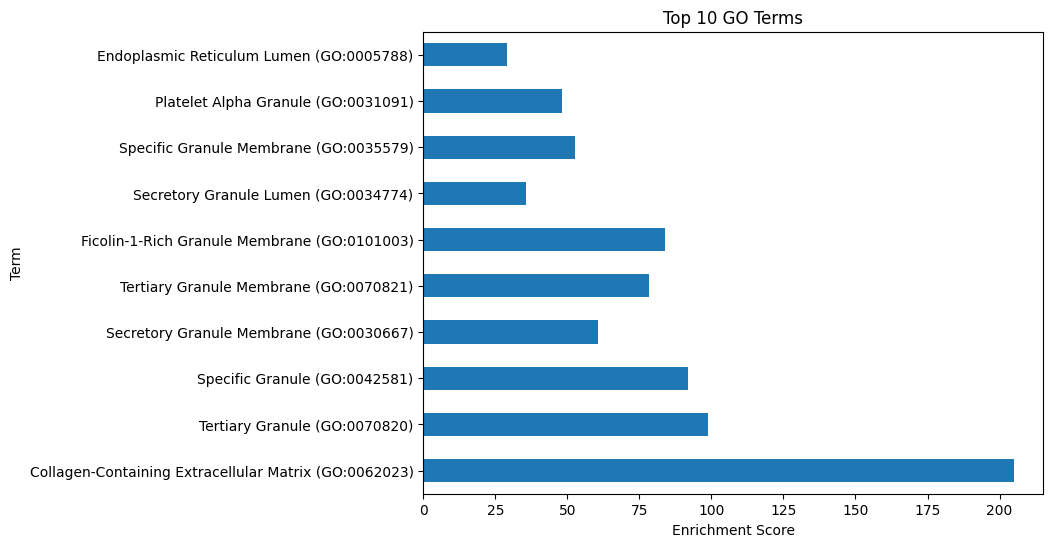

In [2]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

# 1️⃣ Load filtered genes
df = pd.read_csv('filtered_genes.csv')
sig_genes = df[(df['padj'] < 0.05) & (abs(df['log2FoldChange']) > 1)]
gene_list = sig_genes['id'].tolist()

# 2️⃣ GO Enrichment using Enrichr
enr_go = gp.enrichr(
    gene_list=gene_list,
    gene_sets=['GO_Biological_Process_2023',
               'GO_Molecular_Function_2023',
               'GO_Cellular_Component_2023'],
    outdir='GO_results',
    cutoff=0.05
)

# 3️⃣ KEGG / Reactome Pathway Enrichment
enr_pathway = gp.enrichr(
    gene_list=gene_list,
    gene_sets=['KEGG_2021_Human', 'Reactome_2022'],
    outdir='Pathway_results',
    cutoff=0.05
)

# 4️⃣ Visualize Top 10 GO terms (BP example)
enr_go.res2d.sort_values('Adjusted P-value').head(10).plot.barh(
    x='Term', y='Combined Score', legend=False, figsize=(8,6))
plt.xlabel('Enrichment Score')
plt.title('Top 10 GO Terms')
plt.show()


In [6]:
import pandas as pd

# Dictionary of all GO terms you care about
go_terms = {
    "Collagen-containing extracellular matrix": "collagen_extracellular_matrix",
    "Tertiary granule": "tertiary_granule",
    "Specific granule": "specific_granule",
    "Secretory granule membrane": "secretory_granule_membrane",
    "Tertiary granule membrane": "tertiary_granule_membrane",
    "Ficolin-1-rich granule membrane": "ficolin1_rich_granule_membrane",
    "Secretory granule lumen": "secretory_granule_lumen",
    "Specific granule lumen": "specific_granule_lumen",
    "Platelet alpha granule": "platelet_alpha_granule",
    "Endoplasmic reticulum lumen": "endoplasmic_reticulum_lumen",
}

for term, base_name in go_terms.items():
    # find matching row(s)
    rows = enr_go.res2d[enr_go.res2d['Term'].str.contains(term, case=False, na=False)]

    if rows.empty:
        print(f"Term not found in results: {term}")
        continue

    # take first match
    genes_str = rows.iloc[0]['Genes']
    genes = [g.strip() for g in genes_str.split(';')]

    print(f"Genes involved in '{term}':")
    print(genes)

    # save to CSV
    df_genes = pd.DataFrame({'Gene': genes})
    fname = f"{base_name}_genes.csv"
    df_genes.to_csv(fname, index=False)
    print(f"Genes saved to {fname}")


Genes involved in 'Collagen-containing extracellular matrix':
['FCN1', 'SPON1', 'SPARC', 'COL16A1', 'COL12A1', 'SERPINE1', 'LOXL3', 'TNC', 'F13A1', 'CLU', 'EFEMP1', 'CDH2', 'HMCN1', 'TGM2', 'CPA3', 'POSTN', 'COL27A1', 'SERPINF1', 'FIBCD1', 'WNT5A', 'ADAM11', 'PCOLCE', 'NPNT', 'HSPG2', 'SFRP1', 'SLPI', 'COL4A2', 'COL4A1', 'COL8A2', 'S100A6', 'PRTN3', 'S100A4', 'FREM1', 'MXRA5', 'S100A9', 'FREM2', 'S100A8', 'COL17A1', 'FBN2', 'SDC2', 'SDC3', 'FBLN1', 'LTBP2', 'CFP', 'NID1', 'FBLN5', 'VTN', 'SERPINH1', 'APOE', 'A2M', 'ELANE', 'TGFB1', 'COL24A1', 'AMBP', 'RARRES2', 'FN1', 'PRG2', 'PRG4', 'SSC5D', 'PRG3', 'COL1A1', 'COL1A2', 'CXCL12', 'COL5A3', 'COL5A2', 'CNTN1', 'COL9A3', 'CSPG4', 'COL9A2', 'TGFBI', 'FGFR2', 'FBN1', 'FGFR1', 'COL18A1', 'SRPX', 'COL14A1', 'ELN', 'LAMC2', 'LAMC1', 'PCSK6', 'ADAMTSL4', 'ADAMTS1', 'MDK', 'TIMP2', 'TIMP3', 'CTSG', 'EMILIN1', 'CTSF', 'ADAMTS9', 'FGB', 'FGA', 'SERPINB1', 'EGFL7', 'ANXA1', 'DST', 'AHSG', 'MMP2', 'BGN', 'APOA1', 'MMP8', 'DCN', 'VCAN', 'MMRN1', 'ANG

In [10]:
import pandas as pd
import glob

# 1) Read all granule CSV files (adjust pattern if needed)
files = ["/content/endoplasmic_reticulum_lumen_genes.csv",
         "/content/ficolin1_rich_granule_membrane_genes.csv",
         "/content/platelet_alpha_granule_genes.csv",
         "/content/secretory_granule_lumen_genes.csv",
         "/content/secretory_granule_membrane_genes.csv",
         "/content/specific_granule_genes.csv",
         "/content/tertiary_granule_genes.csv",
         "/content/tertiary_granule_membrane_genes.csv",
         "/content/specific_granule_genes.csv"]  # e.g. tertiary_granule_genes.csv, specific_granule_genes.csv, etc.

all_rows = []

for f in files:
    df = pd.read_csv(f)
    # add a column telling from which granule/file this gene came
    granule_name = f.replace("_genes.csv", "")
    df["granule"] = granule_name
    all_rows.append(df)

# Combine everything
all_genes = pd.concat(all_rows, ignore_index=True)

# 2) Count in how many distinct granules each gene appears
gene_granule_counts = (
    all_genes[["Gene", "granule"]]
    .drop_duplicates()
    .groupby("Gene")["granule"]
    .nunique()
    .reset_index(name="n_granules")
)

# 3) Keep only genes that appear in exactly ONE granule (unique granule genes)
unique_genes = gene_granule_counts[gene_granule_counts["n_granules"] == 1]["Gene"]

# 4) Get the corresponding rows (with which granule they belong to)
unique_genes_full = all_genes.merge(unique_genes, on="Gene")

print("Number of genes unique to a single granule:", unique_genes_full["Gene"].nunique())
print(unique_genes_full.head())

# 5) Save to CSV
unique_genes_full.to_csv("granule_unique_genes.csv", index=False)

Number of genes unique to a single granule: 129
      Gene                               granule
0  COL18A1  /content/endoplasmic_reticulum_lumen
1    SPON1  /content/endoplasmic_reticulum_lumen
2  COL16A1  /content/endoplasmic_reticulum_lumen
3     CSF1  /content/endoplasmic_reticulum_lumen
4   FKBP14  /content/endoplasmic_reticulum_lumen


In [ ]:
import pandas as pd
import glob

# 1) Point this pattern to all your granule CSVs
# e.g. if they all end with "_genes.csv"
files = glob.glob("*_genes.csv")

all_rows = []

for f in files:
    df = pd.read_csv(f)
    # assume column name is 'Gene'; if different, change here
    if "Gene" in df.columns:
        all_rows.append(df[["Gene"]])
    else:
        print(f"Skipping {f} as it does not contain a 'Gene' column.")

# 2) Concatenate and drop duplicates
all_genes = pd.concat(all_rows, ignore_index=True)
unique_genes = all_genes.drop_duplicates().reset_index(drop=True)

print("Total unique genes:", len(unique_genes))
print(unique_genes.head())

# 3) Save to a single CSV
unique_genes.to_csv("all_granule_unique_genes.csv", index=False)

unique_list = pd.read_csv("all_granule_unique_genes.csv")["Gene"]
gene_counts_filtered = gene_counts[gene_counts["Gene"].isin(unique_list)]
gene_counts_filtered.to_csv("granule_gene_occurrence_counts_filtered.csv", index=False)



Skipping filtered_genes.csv as it does not contain a 'Gene' column.
Total unique genes: 333
      Gene
0    SPARC
1  SIGLEC9
2    ITGAM
3    MS4A3
4   ITGA2B


NameError: name 'gene_counts' is not defined

In [ ]:
unique_list = pd.read_csv("all_granule_unique_genes.csv")["Gene"]
gene_counts_filtered = gene_counts[gene_counts["Gene"].isin(unique_list)]
gene_counts_filtered.to_csv("granule_gene_occurrence_counts_filtered.csv", index=False)


NameError: name 'gene_counts' is not defined

In [9]:
a = pd.read_csv('filtered_genes.csv')
a.count()
b= pd.read_csv('granule_unique_genes.csv')
b.count()

,0
Gene,165
granule,165
